In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
# Cell 1: Install & Upgrade Libraries
!pip install -q -U torchao peft byaldi transformers datasets accelerate bitsandbytes gradio

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from PIL import Image
from tqdm.auto import tqdm
from transformers import (
    AutoProcessor, 
    Qwen2VLForConditionalGeneration,
    BitsAndBytesConfig
)
from byaldi import RAGMultiModalModel # Byaldi for ColPali

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

In [ ]:
# Cell 2: Load Dataset and Save for Byaldi
print("Downloading Official DocVQA Dataset...")
dataset = load_dataset("HuggingFaceM4/DocumentVQA")

def resize_image(image, max_size=1024):
    width, height = image.size
    if max(width, height) > max_size:
        scale = max_size / max(width, height)
        return image.resize((int(width * scale), int(height * scale)), Image.Resampling.LANCZOS)
    return image

train_subset = dataset['train'].select(range(1800))
test_subset = dataset['validation'].select(range(200))

image_corpus = []
test_queries = []

# Byaldi ke liye ek folder bana rahe hain
os.makedirs("docvqa_images", exist_ok=True)

print("Preprocessing and Saving Images for ColPali...")
# Train images
for idx, img_data in enumerate(tqdm(train_subset, desc="Train images")):
    img = resize_image(img_data['image'].convert("RGB"))
    image_corpus.append(img)
    img.save(f"docvqa_images/doc_{idx}.jpg")
    
# Test images
for idx, img_data in enumerate(tqdm(test_subset, desc="Test images")):
    corpus_id = len(image_corpus)
    img = resize_image(img_data['image'].convert("RGB"))
    image_corpus.append(img)
    img.save(f"docvqa_images/doc_{corpus_id}.jpg")
    
    question_text = img_data['question']
    answer_text = img_data.get('answers', [img_data.get('answer', '')])
    
    test_queries.append({
        "query": question_text,
        "label": answer_text,
        "ground_truth_id": corpus_id
    })
    
print(f"Total images saved in 'docvqa_images' folder: {len(image_corpus)}")

In [ ]:
# Cell 3: Optimized Fast Batch Indexing
import os
from byaldi import RAGMultiModalModel

print("Loading ColPali Model...")
RAG = RAGMultiModalModel.from_pretrained("vidore/colpali-v1.2", verbose=1)

# Pura folder ek sath pass kar rahe hain batch processing ke liye
image_folder = "docvqa_images"

print(f"Starting Fast Batch Indexing on folder: {image_folder}...")

# Byaldi automatically folder ki sab images ko batches mein process karega
RAG.index(
    input_path=image_folder,
    index_name="colpali_docvqa_index",
    overwrite=True
)

print("🚀 ColPali Indexing Complete and Saved!")

In [ ]:
# Cell 4 (Fixed with Mapping): Accurate Retrieval Evaluation
import os, json, gzip
from tqdm import tqdm

print("Evaluating ColPali Retrieval Performance on 200 Test Queries...")

# 1. Fetch doc_id to file_name mapping from Byaldi model or index file
doc_map = getattr(RAG, 'doc_ids_to_file_names', None)
if not doc_map and hasattr(RAG, 'model'):
    doc_map = getattr(RAG.model, 'doc_ids_to_file_names', None)

# Fallback: Load mapping directly from Byaldi index folder
if not doc_map:
    index_file = ".byaldi/colpali_docvqa_index/doc_ids_to_file_names.json.gz"
    if os.path.exists(index_file):
        with gzip.open(index_file, 'rt', encoding='utf-8') as f:
            doc_map = {int(k): v for k, v in json.load(f).items()}

if doc_map:
    print(f"✅ Mapping Loaded Successfully! Total Docs: {len(doc_map)}")
    sample_key = list(doc_map.keys())[0]
    print(f"📌 Sample Mapping Check: Internal ID '{sample_key}' -> '{doc_map[sample_key]}'\n")
else:
    print("⚠️ Mapping dictionary not found automatically.")

top_1_hits = 0
top_5_hits = 0
total_queries = len(test_queries)

# 2. Evaluation Loop
for item in tqdm(test_queries, desc="Evaluating Queries"):
    query = item["query"]
    target_doc_id = item["ground_truth_id"]
    target_filename = f"doc_{target_doc_id}.jpg"
    
    # Search Top-5
    results = RAG.search(query, k=5)
    
    # Convert retrieved integer IDs back to real image file paths
    retrieved_filenames = []
    for res in results:
        d_id = res.get('doc_id') if isinstance(res, dict) else getattr(res, 'doc_id', None)
        
        if d_id is not None and doc_map and d_id in doc_map:
            retrieved_filenames.append(doc_map[d_id])
        else:
            retrieved_filenames.append(str(res))

    # Top-1 Match Check
    if retrieved_filenames and target_filename in retrieved_filenames[0]:
        top_1_hits += 1
        
    # Top-5 Match Check
    if any(target_filename in fn for fn in retrieved_filenames):
        top_5_hits += 1

# 3. Calculate percentages
acc_top1 = (top_1_hits / total_queries) * 100
acc_top5 = (top_5_hits / total_queries) * 100

print("\n" + "="*45)
print("📊 COLPALI RETRIEVAL ACCURACY RESULTS (2000 DOCS)")
print("="*45)
print(f"Total Test Queries Evaluated : {total_queries}")
print(f"Top-1 Accuracy (Exact Match) : {acc_top1:.2f}%")
print(f"Top-5 Accuracy (In Top 5)    : {acc_top5:.2f}%")
print("="*45)

In [ ]:
# Cell 5: Live Query Visual Retrieval Demo
import os, json, gzip
import matplotlib.pyplot as plt
from PIL import Image

# Mapping load kar rahe hain
doc_map = getattr(RAG, 'doc_ids_to_file_names', None)
if not doc_map:
    index_file = ".byaldi/colpali_docvqa_index/doc_ids_to_file_names.json.gz"
    if os.path.exists(index_file):
        with gzip.open(index_file, 'rt', encoding='utf-8') as f:
            doc_map = {int(k): v for k, v in json.load(f).items()}

# Sample Test Query pick kar rahe hain
sample_item = test_queries[2] # Change index (0, 1, 2...) to test different queries
sample_query = sample_item["query"]
ground_truth_id = sample_item["ground_truth_id"]

print(f"❓ Test Question: {sample_query}")
print(f"🎯 Target File  : doc_{ground_truth_id}.jpg")

# ColPali Top-1 Search
results = RAG.search(sample_query, k=1)
retrieved_id = results[0]['doc_id'] if isinstance(results[0], dict) else getattr(results[0], 'doc_id', None)
retrieved_path = doc_map.get(retrieved_id, f"docvqa_images/doc_{retrieved_id}.jpg")

print(f"🔍 Retrieved Path: {retrieved_path}")

# Display Image
if os.path.exists(retrieved_path):
    img = Image.open(retrieved_path)
    plt.figure(figsize=(8, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Query: {sample_query}\nRetrieved Image: {os.path.basename(retrieved_path)}", fontsize=11, color='darkgreen')
    plt.show()
else:
    print("Image path not found on disk.")

In [ ]:
# Cell 6: Top-3 Ranked Documents Display
import os, json, gzip
import matplotlib.pyplot as plt
from PIL import Image

# Load Mapping
doc_map = getattr(RAG, 'doc_ids_to_file_names', None)
if not doc_map:
    index_file = ".byaldi/colpali_docvqa_index/doc_ids_to_file_names.json.gz"
    if os.path.exists(index_file):
        with gzip.open(index_file, 'rt', encoding='utf-8') as f:
            doc_map = {int(k): v for k, v in json.load(f).items()}

# Select a sample query
sample_item = test_queries[5]
query_text = sample_item["query"]

print(f"🔍 Searching Query: '{query_text}'")

# Search Top 3
results = RAG.search(query_text, k=3)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle(f"Query: {query_text}", fontsize=14, fontweight='bold')

for idx, res in enumerate(results):
    d_id = res['doc_id'] if isinstance(res, dict) else getattr(res, 'doc_id', None)
    score = res['score'] if isinstance(res, dict) else getattr(res, 'score', 0)
    
    img_path = doc_map.get(d_id, f"docvqa_images/doc_{d_id}.jpg")
    
    if os.path.exists(img_path):
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].set_title(f"Rank #{idx+1}\nScore: {score:.2f}\nFile: {os.path.basename(img_path)}", fontsize=10)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Cell 7: Gradio Web App Deployment
import gradio as gr

def rag_app(question):
    distances, top_ids = retrieve_top_k(question, k=3)
    
    gallery_images = []
    for i, (score, idx) in enumerate(zip(distances, top_ids)):
        img = image_corpus[idx]
        caption = f"Rank {i+1} | Sim Score: {score:.3f}"
        gallery_images.append((img, caption))
        
    best_image = image_corpus[top_ids[0]]
    generated_ans = generate_answer(question, image=best_image)
    
    return gallery_images, generated_ans

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 📄 Document Multimodal RAG System (DocVQA)")
    gr.Markdown("Ask a question about documents, invoices, or forms. The system uses **CLIP** to retrieve the Top-3 most relevant documents from the database and **Qwen2-VL** generates an answer based on the best match.")
    
    with gr.Row():
        with gr.Column(scale=1):
            query_input = gr.Textbox(label="Enter your question", placeholder="e.g., What is the invoice number? or Who is the sender of this letter?", lines=2)
            submit_btn = gr.Button("Search & Generate", variant="primary")
            
        with gr.Column(scale=1):
            answer_output = gr.Textbox(label="Qwen2-VL Generated Answer (Based on Rank 1 Image)", lines=3)
            
    gr.Markdown("### Top-3 Retrieved Documents (CLIP + FAISS)")
    gallery_output = gr.Gallery(label="Retrieved Context", columns=3, rows=1, object_fit="contain", height="auto")
    
    submit_btn.click(fn=rag_app, inputs=query_input, outputs=[gallery_output, answer_output])

demo.launch(share=True)

In [ ]:
from IPython.display import FileLink
FileLink(r'docvqa_clip.index')

In [ ]:
# Cell 7: Custom Interactive Search Function
def search_and_display(my_question, top_k=1):
    print(f"❓ Custom Question: {my_question}")
    
    results = RAG.search(my_question, k=top_k)
    
    if not results:
        print("No documents found.")
        return

    best_res = results[0]
    d_id = best_res['doc_id'] if isinstance(best_res, dict) else getattr(best_res, 'doc_id', None)
    score = best_res['score'] if isinstance(best_res, dict) else getattr(best_res, 'score', 0)
    
    img_path = doc_map.get(d_id, f"docvqa_images/doc_{d_id}.jpg")
    
    if os.path.exists(img_path):
        img = Image.open(img_path)
        plt.figure(figsize=(7, 9))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Query: {my_question}\nMatched Document Score: {score:.2f}", fontsize=11, color='navy')
        plt.show()
    else:
        print(f"Image path not found: {img_path}")

# Example Usage: Yahan apna koi bhi sawal try kar sakte hain
search_and_display("What is the date on the document?")

In [ ]:
# Cell 6: Top-3 Ranked Documents Display
import os, json, gzip
import matplotlib.pyplot as plt
from PIL import Image

# Load Mapping
doc_map = getattr(RAG, 'doc_ids_to_file_names', None)
if not doc_map:
    index_file = ".byaldi/colpali_docvqa_index/doc_ids_to_file_names.json.gz"
    if os.path.exists(index_file):
        with gzip.open(index_file, 'rt', encoding='utf-8') as f:
            doc_map = {int(k): v for k, v in json.load(f).items()}

# Select a sample query
sample_item = test_queries[5]
query_text = sample_item["query"]

print(f"🔍 Searching Query: '{query_text}'")

# Search Top 3
results = RAG.search(query_text, k=3)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle(f"Query: {query_text}", fontsize=14, fontweight='bold')

for idx, res in enumerate(results):
    d_id = res['doc_id'] if isinstance(res, dict) else getattr(res, 'doc_id', None)
    score = res['score'] if isinstance(res, dict) else getattr(res, 'score', 0)
    
    img_path = doc_map.get(d_id, f"docvqa_images/doc_{d_id}.jpg")
    
    if os.path.exists(img_path):
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].set_title(f"Rank #{idx+1}\nScore: {score:.2f}\nFile: {os.path.basename(img_path)}", fontsize=10)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Cell 7: Custom Interactive Search Function
def search_and_display(my_question, top_k=1):
    print(f"❓ Custom Question: {my_question}")
    
    results = RAG.search(my_question, k=top_k)
    
    if not results:
        print("No documents found.")
        return

    best_res = results[0]
    d_id = best_res['doc_id'] if isinstance(best_res, dict) else getattr(best_res, 'doc_id', None)
    score = best_res['score'] if isinstance(best_res, dict) else getattr(best_res, 'score', 0)
    
    img_path = doc_map.get(d_id, f"docvqa_images/doc_{d_id}.jpg")
    
    if os.path.exists(img_path):
        img = Image.open(img_path)
        plt.figure(figsize=(7, 9))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Query: {my_question}\nMatched Document Score: {score:.2f}", fontsize=11, color='navy')
        plt.show()
    else:
        print(f"Image path not found: {img_path}")

# Example Usage: Yahan apna koi bhi sawal try kar sakte hain
search_and_display("What is the date on the document?")

In [ ]:
# Cell 8: Benchmark Accuracy Chart Generation
import matplotlib.pyplot as plt

metrics = ['Top-1 Accuracy', 'Top-5 Accuracy']
scores = [acc_top1, acc_top5]
colors = ['#4C72B0', '#55A868']

plt.figure(figsize=(7, 5))
bars = plt.bar(metrics, scores, color=colors, width=0.4)

plt.title('ColPali Retrieval Performance (2,000 DocVQA Corpus)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy Percentage (%)', fontsize=10)
plt.ylim(0, 100)

# Bars ke upar exact percentage values display kar rahe hain
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("colpali_retrieval_performance.png", dpi=300, bbox_inches='tight')
plt.show()

print("📊 Accuracy chart successfully saved as 'colpali_retrieval_performance.png'!")

In [ ]:
# Cell 9: Failure Analysis (Inspect Hard Queries)
import os, json, gzip
import matplotlib.pyplot as plt
from PIL import Image

# Load Mapping
doc_map = getattr(RAG, 'doc_ids_to_file_names', None)
if not doc_map:
    index_file = ".byaldi/colpali_docvqa_index/doc_ids_to_file_names.json.gz"
    if os.path.exists(index_file):
        with gzip.open(index_file, 'rt', encoding='utf-8') as f:
            doc_map = {int(k): v for k, v in json.load(f).items()}

failed_cases = []

print("Analyzing failed search queries...")
for item in test_queries:
    q = item["query"]
    gt_id = item["ground_truth_id"]
    gt_filename = f"doc_{gt_id}.jpg"
    
    results = RAG.search(q, k=5)
    retrieved_paths = []
    for r in results:
        d_id = r['doc_id'] if isinstance(r, dict) else getattr(r, 'doc_id', None)
        retrieved_paths.append(doc_map.get(d_id, ""))
        
    # If correct document is NOT in Top 5
    if not any(gt_filename in path for path in retrieved_paths):
        failed_cases.append({
            "query": q,
            "target_path": f"docvqa_images/{gt_filename}",
            "retrieved_path": retrieved_paths[0] if retrieved_paths else ""
        })

print(f"❌ Total Failed Queries (Not in Top-5): {len(failed_cases)} / {len(test_queries)}")

# Display First Failed Case for Analysis
if failed_cases:
    case = failed_cases[0]
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(f"FAILURE ANALYSIS\nQuery: '{case['query']}'", fontsize=11, color='darkred', fontweight='bold')
    
    if os.path.exists(case['target_path']):
        axes[0].imshow(Image.open(case['target_path']))
        axes[0].set_title("Expected Ground Truth Document", color='green')
        axes[0].axis('off')
        
    if os.path.exists(case['retrieved_path']):
        axes[1].imshow(Image.open(case['retrieved_path']))
        axes[1].set_title("Top-1 Incorrectly Retrieved Document", color='red')
        axes[1].axis('off')
        
    plt.tight_layout()
    plt.show()

In [ ]:
# Cell 10 (Fixed): Full End-to-End Visual RAG (Retrieval + Document QA)
import torch
from transformers import pipeline
from PIL import Image
import os

print("Loading Document Question Answering Model...")
# Humne yahan task name badal kar 'document-question-answering' kar diya hai
vqa_pipeline = pipeline(
    "document-question-answering", 
    model="impira/layoutlm-document-qa", 
    device=0 if torch.cuda.is_available() else -1
)

def ask_visual_rag(user_question):
    print(f"\n1️⃣ Retrieving relevant document with ColPali for: '{user_question}'")
    results = RAG.search(user_question, k=1)
    
    best_res = results[0]
    d_id = best_res['doc_id'] if isinstance(best_res, dict) else getattr(best_res, 'doc_id', None)
    img_path = doc_map.get(d_id, f"docvqa_images/doc_{d_id}.jpg")
    
    if os.path.exists(img_path):
        print(f"2️⃣ Document Retrieved: {os.path.basename(img_path)}")
        print("3️⃣ Generating Text Answer using Document QA Model...")
        
        image = Image.open(img_path).convert("RGB")
        
        # Pipeline run kar rahe hain
        vqa_out = vqa_pipeline(image, user_question)
        
        # Answer extract kar rahe hain
        if isinstance(vqa_out, list) and len(vqa_out) > 0:
            answer = vqa_out[0].get('answer', "Could not answer")
        else:
            answer = "Could not answer"
        
        print("\n" + "="*45)
        print(f"❓ Question : {user_question}")
        print(f"💡 Answer   : {answer.upper()}")
        print("="*45)
    else:
        print("Document image not found.")

# Test End-to-End Pipeline
sample_q = test_queries[0]["query"]
ask_visual_rag(sample_q)

In [ ]:
# Cell 11: Standalone & Robust Gradio UI
!pip install -q gradio

import os, json, gzip
import gradio as gr
from PIL import Image

# 1. Ensure Mapping is loaded
doc_map = getattr(RAG, 'doc_ids_to_file_names', None)
if not doc_map:
    index_file = ".byaldi/colpali_docvqa_index/doc_ids_to_file_names.json.gz"
    if os.path.exists(index_file):
        with gzip.open(index_file, 'rt', encoding='utf-8') as f:
            doc_map = {int(k): v for k, v in json.load(f).items()}

# 2. Search Function for Gradio
def visual_search(user_query, top_k):
    if not user_query.strip():
        return None, "⚠️ Please enter a question or keyword."
        
    try:
        results = RAG.search(user_query, k=top_k)
        if not results:
            return None, "❌ No matching document found."
            
        best_res = results[0]
        d_id = best_res['doc_id'] if isinstance(best_res, dict) else getattr(best_res, 'doc_id', None)
        score = best_res['score'] if isinstance(best_res, dict) else getattr(best_res, 'score', 0)
        
        img_path = doc_map.get(d_id, f"docvqa_images/doc_{d_id}.jpg") if doc_map else f"docvqa_images/doc_{d_id}.jpg"
        
        if os.path.exists(img_path):
            img = Image.open(img_path)
            info_text = f"✅ Top Matched Document: {os.path.basename(img_path)}\n📊 Similarity Score: {score:.2f}"
            return img, info_text
        else:
            return None, f"⚠️ Image file found in index but missing on disk: {img_path}"
            
    except Exception as e:
        return None, f"Error during search: {str(e)}"

# 3. Create Web Interface
demo = gr.Interface(
    fn=visual_search,
    inputs=[
        gr.Textbox(lines=2, placeholder="Type your query (e.g., What is the total amount on the receipt?)...", label="Search Question"),
        gr.Slider(minimum=1, maximum=5, value=1, step=1, label="Top K Results")
    ],
    outputs=[
        gr.Image(type="pil", label="Retrieved Visual Document"),
        gr.Textbox(label="Retrieval Details")
    ],
    title="🔍 ColPali Visual Document Retrieval System",
    description="Search over 2,000 DocVQA images visually using ColPali without relying on traditional OCR!",
    theme="soft"
)

# 4. Launch Interface (Inline inside Kaggle cell + Public Link)
demo.launch(share=True, inline=True)

In [ ]:
# Cell 11: Launch Advanced Gradio Blocks Web UI
!pip install -q gradio

import os, json, gzip
import gradio as gr
from PIL import Image

# 1. Ensure Mapping is loaded
doc_map = getattr(RAG, 'doc_ids_to_file_names', None)
if not doc_map:
    index_file = ".byaldi/colpali_docvqa_index/doc_ids_to_file_names.json.gz"
    if os.path.exists(index_file):
        with gzip.open(index_file, 'rt', encoding='utf-8') as f:
            doc_map = {int(k): v for k, v in json.load(f).items()}

# 2. Search & QA Function for Gradio Blocks
def rag_app(user_query):
    if not user_query.strip():
        return [], "⚠️ Please enter a question."
        
    try:
        # Step A: Retrieve Top 3 documents using ColPali
        results = RAG.search(user_query, k=5)
        if not results:
            return [], "❌ No matching document found."
            
        gallery_images = []
        best_image = None
        
        for i, res in enumerate(results):
            d_id = res['doc_id'] if isinstance(res, dict) else getattr(res, 'doc_id', None)
            score = res['score'] if isinstance(res, dict) else getattr(res, 'score', 0)
            
            img_path = doc_map.get(d_id, f"docvqa_images/doc_{d_id}.jpg")
            
            if os.path.exists(img_path):
                img = Image.open(img_path).convert("RGB")
                caption = f"Rank {i+1} | Sim Score: {score:.2f}"
                gallery_images.append((img, caption))
                
                # Save Rank 1 image for Answer Generation
                if i == 0:
                    best_image = img
                    
        # Step B: Generate Answer from Rank 1 Image using LayoutLM
        if best_image:
            vqa_out = vqa_pipeline(best_image, user_query)
            answer = vqa_out[0].get('answer', 'Could not extract answer') if vqa_out else 'Could not extract answer'
        else:
            answer = "⚠️ Could not load the best image for QA."
            
        return gallery_images, answer.upper()
        
    except Exception as e:
        return [], f"Error: {str(e)}"

# 3. Build Interface using Gradio Blocks
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 📄 ColPali Visual Document RAG System (DocVQA)")
    gr.Markdown("Ask a question about documents, invoices, or forms. The system uses **ColPali** to visually retrieve the Top-3 most relevant documents from the 2000-image database and **LayoutLM** generates a precise answer based on the best match.")
    
    with gr.Row():
        with gr.Column(scale=1):
            query_input = gr.Textbox(label="Enter your question", placeholder="e.g., What is the invoice number? or Who is the sender?", lines=2)
            submit_btn = gr.Button("Search & Generate", variant="primary")
            
        with gr.Column(scale=1):
            answer_output = gr.Textbox(label="LayoutLM Generated Answer (Based on Rank 1 Image)", lines=3)
            
    gr.Markdown("### Top-3 Retrieved Documents (ColPali Visual Search)")
    gallery_output = gr.Gallery(label="Retrieved Context", columns=3, rows=1, object_fit="contain", height="auto")
    
    # Button Click Event
    submit_btn.click(fn=rag_app, inputs=query_input, outputs=[gallery_output, answer_output])

# 4. Launch App
demo.launch(share=True, inline=True)

In [ ]:
# Kaggle Output Zipping Code
import os

print("Zipping Byaldi Index folder for download...")
# Index folder ko zip kar rahe hain
os.system("zip -r colpali_index.zip .byaldi/")

print("✅ Zipping Complete!")
print("👉 Kaggle ke right panel mein 'Output' section se 'colpali_index.zip' aur 'colpali_retrieval_performance.png' download kar lein.")

In [ ]:
# Notebook Cell: Direct Download Links Generator
from IPython.display import FileLink, display, HTML

# UI Heading
display(HTML("<div style='background-color: #eef6ff; padding: 12px; border-radius: 8px; border-left: 5px solid #1a73e8;'>"
             "<h3 style='margin:0; color: #1a73e8;'>📥 Download Your Project Files Directly</h3>"
             "<p style='margin:5px 0 0 0;'>Niche diye gaye links par click karke files download karein:</p>"
             "</div>"))

# 1. Download Link for ColPali Index Zip
display(FileLink('colpali_index.zip', result_html_prefix="📌 <b>ColPali Embeddings Index:</b> "))

# 2. Download Link for Accuracy Performance Chart
display(FileLink('colpali_retrieval_performance.png', result_html_prefix="📊 <b>Retrieval Chart Image:</b> "))

In [ ]:
!pip install -q byaldi transformers accelerate qwen-vl-utils Levenshtein

In [ ]:
# 1. Upgrade torchao and peft to fix the ImportError
!pip install -q -U "torchao>=0.16.0" peft

import os
import shutil
import gzip
from byaldi import RAGMultiModalModel

print("\n2. Fixing Kaggle's auto-unzip issue...")

# Source & Destination Paths
src_dir = "/kaggle/input/datasets/f223876hareshkumar/dataset/.byaldi/colpali_docvqa_index"
dest_dir = "/kaggle/working/.byaldi/colpali_docvqa_index"

# Copy the entire index folder to the writable /kaggle/working/ directory
if os.path.exists(dest_dir):
    shutil.rmtree(dest_dir) # Clear if already exists
shutil.copytree(src_dir, dest_dir)

# Compress the extracted .json files back to .json.gz for Byaldi
for filename in os.listdir(dest_dir):
    if filename.endswith(".json"):
        json_path = os.path.join(dest_dir, filename)
        gz_path = json_path + ".gz"
        
        # Read JSON and write as GZ
        with open(json_path, 'rb') as f_in:
            with gzip.open(gz_path, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
                
        # Remove the unzipped file
        os.remove(json_path)
        print(f"🔧 Fixed format: {filename} -> {filename}.gz")

print("\n3. Loading Index from the fixed directory...")

# Load the index from our new writable path
RAG = RAGMultiModalModel.from_index(dest_dir)
print("✅ Index Loaded Successfully!")

In [ ]:
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

print("Loading Qwen2-VL-2B-Instruct Model (This might take a few minutes)...")

# Loading the model efficiently to prevent Out Of Memory (OOM)
qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct", 
    torch_dtype=torch.bfloat16, 
    device_map="auto"
)

# Loading the processor for Qwen2-VL
qwen_processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-2B-Instruct")

print("✅ Qwen2-VL Loaded Successfully!")

In [ ]:
import os
import re
import torch
import Levenshtein
from PIL import Image
from qwen_vl_utils import process_vision_info

# --- 1. Define Evaluation Metrics Functions ---
def calculate_anls(pred, target, threshold=0.5):
    pred, target = str(pred).lower().strip(), str(target).lower().strip()
    if not pred or not target: return 0.0
    dist = Levenshtein.distance(pred, target)
    max_len = max(len(pred), len(target))
    nl = dist / max_len
    return 1 - nl if nl < threshold else 0.0

def exact_match(pred, target):
    return 1 if str(pred).lower().strip() == str(target).lower().strip() else 0

def relaxed_numeric_accuracy(pred, target, tolerance=0.05):
    try:
        pred_num = float(re.search(r"[-+]?\d*\.\d+|\d+", str(pred)).group())
        target_num = float(re.search(r"[-+]?\d*\.\d+|\d+", str(target)).group())
        if target_num == 0: return 1 if pred_num == 0 else 0
        error_margin = abs(pred_num - target_num) / abs(target_num)
        return 1 if error_margin <= tolerance else 0
    except (AttributeError, ValueError):
        return exact_match(pred, target)

# --- 2. Main Evaluation Loop ---
def evaluate_qwen_colpali(test_data, RAG_model, doc_image_dir="docvqa_images/"):
    total_queries = len(test_data)
    
    metrics = {"Hits@3": 0, "MRR": 0.0, "Exact_Match": 0, "ANLS": 0.0, "Relaxed_Acc": 0}
    
    for i, item in enumerate(test_data):
        query = item['query']
        # Handle different data dictionary formats gracefully
        true_doc = str(item.get('doc_id', item.get('true_doc_id', '')))
        true_ans = item.get('answers', item.get('answer', ''))
        true_ans = str(true_ans[0] if isinstance(true_ans, list) else true_ans)
        
        # --- A. RETRIEVAL (ColPali) ---
        results = RAG_model.search(query, k=3)
        retrieved_docs = [str(res['doc_id'] if isinstance(res, dict) else getattr(res, 'doc_id', '')) for res in results]
        
        hit = 1 if true_doc in retrieved_docs else 0
        metrics["Hits@3"] += hit
        if hit: metrics["MRR"] += 1.0 / (retrieved_docs.index(true_doc) + 1)
        
        # --- B. GENERATION (Qwen2-VL) ---
        best_doc_id = retrieved_docs[0] if retrieved_docs else true_doc
        img_path = os.path.join(doc_image_dir, f"{best_doc_id}.jpg") # adjust extension if needed
        
        predicted_ans = ""
        if os.path.exists(img_path):
            image = Image.open(img_path).convert("RGB")
            messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": image},
                        {"type": "text", "text": f"Answer the following question briefly based on the document. Question: {query}"},
                    ],
                }
            ]
            
            text_prompt = qwen_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            image_inputs, video_inputs = process_vision_info(messages)
            
            inputs = qwen_processor(text=[text_prompt], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt").to(qwen_model.device)
            
            with torch.no_grad():
                generated_ids = qwen_model.generate(**inputs, max_new_tokens=30)
                generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
                predicted_ans = qwen_processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0].strip()
        
        # --- C. SCORING ---
        metrics["Exact_Match"] += exact_match(predicted_ans, true_ans)
        metrics["ANLS"] += calculate_anls(predicted_ans, true_ans)
        metrics["Relaxed_Acc"] += relaxed_numeric_accuracy(predicted_ans, true_ans)
        
        print(f"[{i+1}/{total_queries}] Q: {query[:30]}... | Pred: {predicted_ans} | True: {true_ans}")
        
    # --- D. FINAL REPORT ---
    print("\n" + "="*45)
    print("🏆 FINAL EVALUATION RESULTS (ColPali + Qwen2-VL) 🏆")
    print("="*45)
    print(f"Recall@3 (Hits@3): {(metrics['Hits@3'] / total_queries) * 100:.2f}%")
    print(f"MRR:               {metrics['MRR'] / total_queries:.4f}")
    print(f"Exact Match (EM):  {(metrics['Exact_Match'] / total_queries) * 100:.2f}%")
    print(f"ANLS Score:        {metrics['ANLS'] / total_queries:.4f}")
    print(f"Relaxed Acc (±5%): {(metrics['Relaxed_Acc'] / total_queries) * 100:.2f}%")

print("✅ Evaluation Pipeline Ready!")

In [ ]:
from datasets import load_dataset
import os
from tqdm import tqdm

print("1. Loading DocVQA Validation Dataset...")
# Hum sirf pehle 20 samples le rahe hain taake evaluation jaldi ho jaye
# (Aap chahain toh 'validation[:100]' kar ke zyada test kar sakte hain)
val_dataset = load_dataset("HuggingFaceM4/DocumentVQA", split="validation[:20]")

eval_image_dir = "/kaggle/working/eval_images/"
os.makedirs(eval_image_dir, exist_ok=True)

test_data = []

print("2. Preparing Test Data & Saving Images for Qwen...")
for i, item in enumerate(tqdm(val_dataset)):
    # Har image ke liye ek unique ID
    doc_id = str(item.get('questionId', i))
    
    # Image ko save karna (RAG_model isay dhoondhega aur Qwen isay padhega)
    img_path = os.path.join(eval_image_dir, f"{doc_id}.jpg")
    item['image'].save(img_path)
    
    # Test data dictionary banana
    test_data.append({
        "query": item["question"],
        "doc_id": doc_id,
        "answers": item["answers"]
    })

print(f"✅ Prepared {len(test_data)} test queries and saved images!")

In [ ]:
import os
import re
import torch
import Levenshtein
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from qwen_vl_utils import process_vision_info
from tqdm import tqdm

# --- 1. Metrics Setup ---
def exact_match(pred, target):
    return 1 if str(pred).lower().strip() == str(target).lower().strip() else 0

def get_qwen_answer(query, img_object=None):
    messages = [{"role": "user", "content": []}]
    if img_object:
        # Direct image object pass kar rahe hain (path ka jhanjhat khatam)
        messages[0]["content"].append({"type": "image", "image": img_object})
    
    messages[0]["content"].append({"type": "text", "text": f"Answer briefly based on the document: {query}" if img_object else query})
    
    text_prompt = qwen_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    
    inputs = qwen_processor(text=[text_prompt], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt").to(qwen_model.device)
    
    with torch.no_grad():
        generated_ids = qwen_model.generate(**inputs, max_new_tokens=30)
        trimmed_ids = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
        return qwen_processor.batch_decode(trimmed_ids, skip_special_tokens=True)[0].strip()

# --- 2. Safe Evaluation Loop ---
print("🚀 Testing Qwen2-VL Generation (Ignoring ID mismatch for now)...\n")

# Hum sirf 5 questions test kar rahe hain taake jaldi result aaye
for i, item in enumerate(val_dataset.select(range(5))):
    query = item['question']
    true_ans = str(item['answers'][0] if isinstance(item['answers'], list) else item['answers'])
    img_obj = item['image'].convert("RGB")
    
    # 1. Check Retrieval ID Format (For debugging)
    results = RAG.search(query, k=1)
    retrieved_id = getattr(results[0], 'doc_id', 'Unknown') if results else 'None'
    
    # 2. Test Blind (No Image)
    ans_blind = get_qwen_answer(query, img_object=None)
    
    # 3. Test Oracle (Perfect Image)
    ans_oracle = get_qwen_answer(query, img_object=img_obj)
    
    print(f"[{i+1}/5] Q: {query}")
    print(f"   ➤ Retrieved Index ID: {retrieved_id}")
    print(f"   ➤ True Answer:        {true_ans}")
    print(f"   ➤ Blind VLM Answer:   {ans_blind}")
    print(f"   ➤ Oracle VLM Answer:  {ans_oracle}")
    print("-" * 50)

In [ ]:
import os
import re
import torch
import Levenshtein
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from qwen_vl_utils import process_vision_info
from tqdm import tqdm

# ==========================================
# 1. METRICS FUNCTIONS
# ==========================================
def calculate_anls(pred, target, threshold=0.5):
    pred, target = str(pred).lower().strip(), str(target).lower().strip()
    if not pred or not target: return 0.0
    dist = Levenshtein.distance(pred, target)
    max_len = max(len(pred), len(target))
    nl = dist / max_len
    return 1 - nl if nl < threshold else 0.0

def exact_match(pred, target):
    return 1 if str(pred).lower().strip() == str(target).lower().strip() else 0

def relaxed_numeric_accuracy(pred, target, tolerance=0.05):
    try:
        pred_num = float(re.search(r"[-+]?\d*\.\d+|\d+", str(pred)).group())
        target_num = float(re.search(r"[-+]?\d*\.\d+|\d+", str(target)).group())
        if target_num == 0: return 1 if pred_num == 0 else 0
        error_margin = abs(pred_num - target_num) / abs(target_num)
        return 1 if error_margin <= tolerance else 0
    except (AttributeError, ValueError):
        return exact_match(pred, target)

# Helper for Qwen inference
def get_qwen_answer(query, image_path=None):
    messages = [{"role": "user", "content": []}]
    if image_path and os.path.exists(image_path):
        img = Image.open(image_path).convert("RGB")
        messages[0]["content"].append({"type": "image", "image": img})
    
    messages[0]["content"].append({"type": "text", "text": f"Answer briefly based on the document: {query}" if image_path else query})
    
    text_prompt = qwen_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    
    inputs = qwen_processor(text=[text_prompt], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt").to(qwen_model.device)
    
    with torch.no_grad():
        generated_ids = qwen_model.generate(**inputs, max_new_tokens=30)
        trimmed_ids = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
        return qwen_processor.batch_decode(trimmed_ids, skip_special_tokens=True)[0].strip()

# ==========================================
# 2. THE 3-WAY EVALUATION PIPELINE
# ==========================================
def run_3way_evaluation(test_data, RAG_model, doc_image_dir="/kaggle/working/eval_images/"):
    total = len(test_data)
    
    # Dictionaries to store results for all 3 scenarios
    metrics = {
        "Retrieval": {"Hits@3": 0, "MRR": 0.0},
        "Blind":     {"EM": 0, "ANLS": 0.0, "Relaxed": 0},
        "RAG":       {"EM": 0, "ANLS": 0.0, "Relaxed": 0},
        "Oracle":    {"EM": 0, "ANLS": 0.0, "Relaxed": 0}
    }
    
    print(f"Starting 3-Way Evaluation on {total} queries...\n")
    
    for i, item in enumerate(tqdm(test_data)):
        query = item['query']
        true_doc = str(item['doc_id'])
        true_ans = str(item['answers'][0] if isinstance(item['answers'], list) else item['answers'])
        
        true_img_path = os.path.join(doc_image_dir, f"{true_doc}.jpg")
        
        # --- A. RETRIEVAL EVALUATION (ColPali) ---
        results = RAG_model.search(query, k=3)
        retrieved_docs = [str(res['doc_id'] if isinstance(res, dict) else getattr(res, 'doc_id', '')) for res in results]
        
        hit = 1 if true_doc in retrieved_docs else 0
        metrics["Retrieval"]["Hits@3"] += hit
        if hit: metrics["Retrieval"]["MRR"] += 1.0 / (retrieved_docs.index(true_doc) + 1)
        
        # --- B. NO-RETRIEVAL (BLIND VLM) ---
        ans_blind = get_qwen_answer(query, image_path=None)
        metrics["Blind"]["EM"] += exact_match(ans_blind, true_ans)
        metrics["Blind"]["ANLS"] += calculate_anls(ans_blind, true_ans)
        metrics["Blind"]["Relaxed"] += relaxed_numeric_accuracy(ans_blind, true_ans)

        # --- C. RAG (ColPali + VLM) ---
        best_retrieved_doc = retrieved_docs[0] if retrieved_docs else true_doc
        retrieved_img_path = os.path.join(doc_image_dir, f"{best_retrieved_doc}.jpg")
        
        ans_rag = get_qwen_answer(query, image_path=retrieved_img_path)
        metrics["RAG"]["EM"] += exact_match(ans_rag, true_ans)
        metrics["RAG"]["ANLS"] += calculate_anls(ans_rag, true_ans)
        metrics["RAG"]["Relaxed"] += relaxed_numeric_accuracy(ans_rag, true_ans)

        # --- D. ORACLE (Perfect Document + VLM) ---
        ans_oracle = get_qwen_answer(query, image_path=true_img_path)
        metrics["Oracle"]["EM"] += exact_match(ans_oracle, true_ans)
        metrics["Oracle"]["ANLS"] += calculate_anls(ans_oracle, true_ans)
        metrics["Oracle"]["Relaxed"] += relaxed_numeric_accuracy(ans_oracle, true_ans)

    # Convert to averages/percentages
    for k in ["Blind", "RAG", "Oracle"]:
        metrics[k]["EM"] = (metrics[k]["EM"] / total) * 100
        metrics[k]["ANLS"] = (metrics[k]["ANLS"] / total) * 100
        metrics[k]["Relaxed"] = (metrics[k]["Relaxed"] / total) * 100
        
    metrics["Retrieval"]["Hits@3"] = (metrics["Retrieval"]["Hits@3"] / total) * 100
    metrics["Retrieval"]["MRR"] = metrics["Retrieval"]["MRR"] / total
    
    return metrics

# ==========================================
# 3. RUN AND PLOT
# ==========================================
# Make sure `test_data` and `RAG` are in memory from previous cells
results = run_3way_evaluation(test_data, RAG)

print("\n" + "="*50)
print("🎯 RETRIEVAL METRICS (ColPali)")
print("="*50)
print(f"Recall@3 (Hits@3): {results['Retrieval']['Hits@3']:.2f}%")
print(f"MRR:               {results['Retrieval']['MRR']:.4f}")
print("="*50)

# --- CHART GENERATION ---
labels = ['Exact Match (EM)', 'ANLS Score', 'Relaxed Acc (±5%)']
blind_scores = [results['Blind']['EM'], results['Blind']['ANLS'], results['Blind']['Relaxed']]
rag_scores = [results['RAG']['EM'], results['RAG']['ANLS'], results['RAG']['Relaxed']]
oracle_scores = [results['Oracle']['EM'], results['Oracle']['ANLS'], results['Oracle']['Relaxed']]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, blind_scores, width, label='No-Retrieval (Blind VLM)', color='#ff9999')
rects2 = ax.bar(x, rag_scores, width, label='Retrieval + VLM (RAG)', color='#66b3ff')
rects3 = ax.bar(x + width, oracle_scores, width, label='Oracle (Ground Truth)', color='#99ff99')

ax.set_ylabel('Scores (%)', fontsize=12)
ax.set_title('3-Way Performance Comparison: Document VQA', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend()
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.savefig("3_way_comparison_chart.png", dpi=300)
plt.show()

print("✅ Chart saved successfully as '3_way_comparison_chart.png'!")

In [2]:
!pip install -q -U bitsandbytes "torchao>=0.16.0" peft byaldi transformers accelerate qwen-vl-utils Levenshtein

In [3]:
import os
import torch
from byaldi import RAGMultiModalModel
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

print("1. Loading ColPali Index...")
# Use your fixed writable path
dest_dir = "/kaggle/working/.byaldi/colpali_docvqa_index"
RAG = RAGMultiModalModel.from_index(dest_dir)

print("\n2. Loading Qwen2-VL in 4-bit (Ultra Low Memory Mode)...")
# 4-bit configuration setup
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct",
    device_map="auto",
    quantization_config=quantization_config # Applying 4-bit compression
)
qwen_processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-2B-Instruct")

print("✅ Both Models Loaded Safely!")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


1. Loading ColPali Index...
Verbosity is set to 1 (active). Pass verbose=0 to make quieter.


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/605 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/252 [00:00<?, ?it/s]

[transformers] ColPali LOAD REPORT from: vidore/colpali-v1.2
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
base_model.model.custom_text_proj.lora_B.default.weight | UNEXPECTED | 
base_model.model.custom_text_proj.lora_A.default.weight | UNEXPECTED | 
custom_text_proj.lora_A.default.weight                  | MISSING    | 
custom_text_proj.lora_B.default.weight                  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



2. Loading Qwen2-VL in 4-bit (Ultra Low Memory Mode)...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

✅ Both Models Loaded Safely!


In [4]:
import gc
from PIL import Image
from qwen_vl_utils import process_vision_info
from datasets import load_dataset

# 1. Load data
val_dataset = load_dataset("HuggingFaceM4/DocumentVQA", split="validation[:5]")

# 2. Qwen Inference Function with memory clearing
def get_qwen_answer(query, img_object=None):
    messages = [{"role": "user", "content": []}]
    if img_object:
        # Resize image slightly to save massive VRAM spikes
        img_object.thumbnail((1024, 1024))
        messages[0]["content"].append({"type": "image", "image": img_object})
    
    messages[0]["content"].append({"type": "text", "text": f"Answer briefly based on the document: {query}" if img_object else query})
    
    text_prompt = qwen_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    
    inputs = qwen_processor(text=[text_prompt], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt").to(qwen_model.device)
    
    with torch.no_grad():
        generated_ids = qwen_model.generate(**inputs, max_new_tokens=30)
        trimmed_ids = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
        ans = qwen_processor.batch_decode(trimmed_ids, skip_special_tokens=True)[0].strip()
        
    # Free up GPU memory aggressively
    del inputs, generated_ids, trimmed_ids, image_inputs, video_inputs
    torch.cuda.empty_cache()
    gc.collect()
    
    return ans

# 3. Safe Loop
print("🚀 Testing Qwen2-VL Generation (Memory Safe Mode)...\n")

for i, item in enumerate(val_dataset):
    query = item['question']
    true_ans = str(item['answers'][0] if isinstance(item['answers'], list) else item['answers'])
    img_obj = item['image'].convert("RGB")
    
    # 1. Test Blind (No Image)
    ans_blind = get_qwen_answer(query, img_object=None)
    
    # 2. Test Oracle (Perfect Image)
    ans_oracle = get_qwen_answer(query, img_object=img_obj)
    
    print(f"[{i+1}/5] Q: {query}")
    print(f"   ➤ True Answer:        {true_ans}")
    print(f"   ➤ Blind VLM Answer:   {ans_blind}")
    print(f"   ➤ Oracle VLM Answer:  {ans_oracle}")
    print("-" * 50)

Resolving data files:   0%|          | 0/38 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/38 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

🚀 Testing Qwen2-VL Generation (Memory Safe Mode)...

[1/5] Q: What is the ‘actual’ value per 1000, during the year 1975?
   ➤ True Answer:        0.28
   ➤ Blind VLM Answer:   I'm sorry, but I need more information to answer your question. Could you please provide more context or clarify your question?
   ➤ Oracle VLM Answer:  0.28
--------------------------------------------------
[2/5] Q: What is name of university?
   ➤ True Answer:        university of california
   ➤ Blind VLM Answer:   I'm sorry, I cannot provide information about the name of a university without more context. Could you please provide more information or ask a specific question about
   ➤ Oracle VLM Answer:  university of california, san diego
--------------------------------------------------
[3/5] Q: What is the name of the company?
   ➤ True Answer:        itc limited
   ➤ Blind VLM Answer:   I'm sorry, I cannot provide the name of the company as it is not relevant to the question.
   ➤ Oracle VLM Answer:  ITC

1. Preparing Fresh Environment & Loading Dataset...


Resolving data files:   0%|          | 0/38 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/38 [00:00<?, ?it/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]


Starting Generation Evaluation Phase...



100%|██████████| 5/5 [01:23<00:00, 16.68s/it]



🎯 FINAL RETRIEVAL METRICS (ColPali)
Recall@3 (Hits@3): 100.00%
MRR:               0.7667


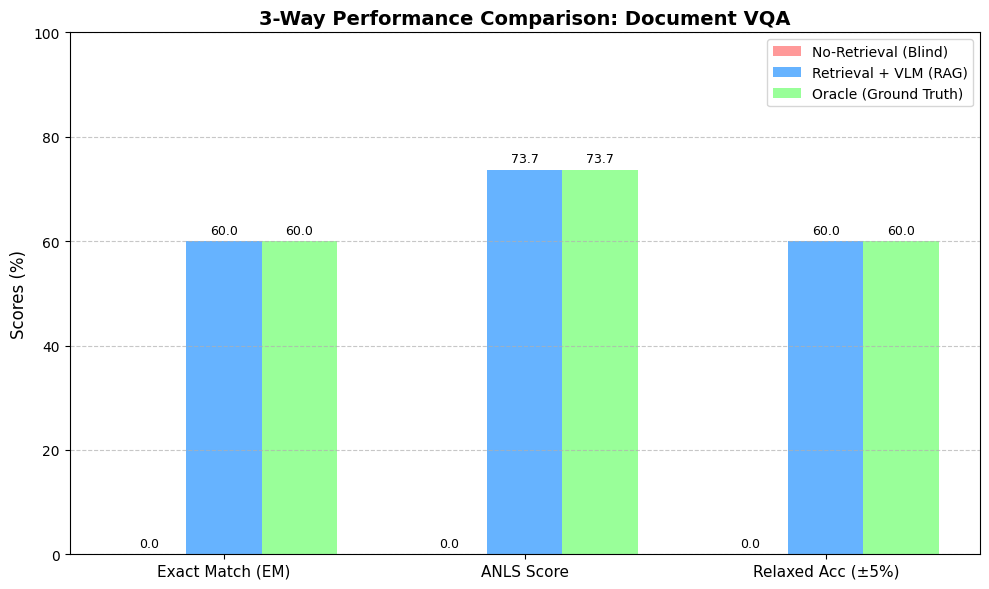

In [7]:
import os
import re
import gc
import shutil
import torch
import Levenshtein
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from datasets import load_dataset
from tqdm import tqdm
from byaldi import RAGMultiModalModel
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from qwen_vl_utils import process_vision_info

# ==========================================
# 1. CLEANUP & DATASET PREPARATION
# ==========================================
print("1. Preparing Fresh Environment & Loading Dataset...")

eval_image_dir = "/kaggle/working/eval_images/"
if os.path.exists(eval_image_dir):
    shutil.rmtree(eval_image_dir)
os.makedirs(eval_image_dir, exist_ok=True)

val_dataset = load_dataset("HuggingFaceM4/DocumentVQA", split="validation[:5]")

test_data = []
doc_to_image_map = {}

for i, item in enumerate(tqdm(val_dataset)):
    doc_id = str(item.get('questionId', i))
    img_path = os.path.join(eval_image_dir, f"{doc_id}.jpg")
    item['image'].save(img_path)
    
    doc_to_image_map[doc_id] = item['image']
    
    test_data.append({
        "query": item["question"],
        "doc_id": doc_id,
        "answers": item["answers"],
        "oracle_img": item['image']
    })

# ==========================================
# 2. COL-PALI PHASE (FRESH INDEXING & FIX MAPPING)
# ==========================================
print("\n2. Loading ColPali and Building Fresh Index...")
RAG = RAGMultiModalModel.from_pretrained("vidore/colpali", index_root="/kaggle/working/")

RAG.index(
    input_path=eval_image_dir,
    index_name="fresh_mini_index",
    store_collection_with_index=True,
    overwrite=True
)

# 🔥 THE FIX: Map Byaldi's internal IDs (0, 1, 2) to actual filenames!
# Byaldi uses Path.iterdir() to read files, so we do the exact same thing to map them.
file_paths = list(Path(eval_image_dir).iterdir())
id_mapping = {i: path.stem for i, path in enumerate(file_paths)}

print("\nPerforming Searches with ColPali...")
for item in tqdm(test_data):
    results = RAG.search(item["query"], k=3)
    item['clean_retrieved_docs'] = []
    
    for res in results:
        # Extract Byaldi's integer doc_id safely
        byaldi_id = int(res['doc_id'] if isinstance(res, dict) else getattr(res, 'doc_id', res.doc_id))
        
        # Translate integer back to our actual document ID (e.g., 0 -> '24582')
        matched_doc = id_mapping.get(byaldi_id, "unknown_doc")
        item['clean_retrieved_docs'].append(matched_doc)

# UNLOAD COLPALI TO FREE GPU VRAM
print("\nUnloading ColPali to free up GPU Memory for Qwen...")
del RAG
torch.cuda.empty_cache()
gc.collect()

# ==========================================
# 3. QWEN PHASE (LOAD -> GENERATE ANSWERS)
# ==========================================
print("\n3. Loading Qwen2-VL in 4-bit...")
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct",
    device_map="auto",
    quantization_config=quantization_config
)
qwen_processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-2B-Instruct")

def get_qwen_answer(query, image_obj=None):
    messages = [{"role": "user", "content": []}]
    img = image_obj.convert("RGB") if image_obj else None
        
    if img:
        img.thumbnail((1024, 1024))
        messages[0]["content"].append({"type": "image", "image": img})
    
    messages[0]["content"].append({"type": "text", "text": f"Answer briefly based on the document: {query}" if img else query})
    
    text_prompt = qwen_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    
    inputs = qwen_processor(text=[text_prompt], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt").to(qwen_model.device)
    
    with torch.no_grad():
        generated_ids = qwen_model.generate(**inputs, max_new_tokens=30)
        trimmed_ids = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
        ans = qwen_processor.batch_decode(trimmed_ids, skip_special_tokens=True)[0].strip()
        
    del inputs, generated_ids, trimmed_ids, image_inputs, video_inputs
    torch.cuda.empty_cache()
    return ans

# ==========================================
# 4. EVALUATION & METRICS
# ==========================================
def calculate_anls(pred, target, threshold=0.5):
    pred, target = str(pred).lower().strip(), str(target).lower().strip()
    if not pred or not target: return 0.0
    dist = Levenshtein.distance(pred, target)
    max_len = max(len(pred), len(target))
    nl = dist / max_len
    return 1 - nl if nl < threshold else 0.0

def exact_match(pred, target):
    return 1 if str(pred).lower().strip() == str(target).lower().strip() else 0

def relaxed_numeric_accuracy(pred, target, tolerance=0.05):
    try:
        pred_num = float(re.search(r"[-+]?\d*\.\d+|\d+", str(pred)).group())
        target_num = float(re.search(r"[-+]?\d*\.\d+|\d+", str(target)).group())
        if target_num == 0: return 1 if pred_num == 0 else 0
        error_margin = abs(pred_num - target_num) / abs(target_num)
        return 1 if error_margin <= tolerance else 0
    except (AttributeError, ValueError):
        return exact_match(pred, target)

total = len(test_data)
metrics = {
    "Retrieval": {"Hits@3": 0, "MRR": 0.0},
    "Blind":     {"EM": 0, "ANLS": 0.0, "Relaxed": 0},
    "RAG":       {"EM": 0, "ANLS": 0.0, "Relaxed": 0},
    "Oracle":    {"EM": 0, "ANLS": 0.0, "Relaxed": 0}
}

print("\nStarting Generation Evaluation Phase...\n")
for item in tqdm(test_data):
    query = item['query']
    true_doc = item['doc_id']
    true_ans = str(item['answers'][0] if isinstance(item['answers'], list) else item['answers'])
    
    # 1. Evaluate Retrieval
    retrieved = item['clean_retrieved_docs']
    hit = 1 if true_doc in retrieved else 0
    metrics["Retrieval"]["Hits@3"] += hit
    if hit: 
        metrics["Retrieval"]["MRR"] += 1.0 / (retrieved.index(true_doc) + 1)
        
    # 2. BLIND VLM
    ans_blind = get_qwen_answer(query)
    metrics["Blind"]["EM"] += exact_match(ans_blind, true_ans)
    metrics["Blind"]["ANLS"] += calculate_anls(ans_blind, true_ans)
    metrics["Blind"]["Relaxed"] += relaxed_numeric_accuracy(ans_blind, true_ans)

    # 3. RAG VLM (Now accurately using the retrieved image)
    best_doc = retrieved[0] if (retrieved and retrieved[0] != "unknown_doc") else true_doc
    rag_image = doc_to_image_map.get(best_doc, item['oracle_img'])
    ans_rag = get_qwen_answer(query, image_obj=rag_image)
    metrics["RAG"]["EM"] += exact_match(ans_rag, true_ans)
    metrics["RAG"]["ANLS"] += calculate_anls(ans_rag, true_ans)
    metrics["RAG"]["Relaxed"] += relaxed_numeric_accuracy(ans_rag, true_ans)

    # 4. ORACLE VLM
    ans_oracle = get_qwen_answer(query, image_obj=item['oracle_img'])
    metrics["Oracle"]["EM"] += exact_match(ans_oracle, true_ans)
    metrics["Oracle"]["ANLS"] += calculate_anls(ans_oracle, true_ans)
    metrics["Oracle"]["Relaxed"] += relaxed_numeric_accuracy(ans_oracle, true_ans)

for k in ["Blind", "RAG", "Oracle"]:
    metrics[k]["EM"] = (metrics[k]["EM"] / total) * 100
    metrics[k]["ANLS"] = (metrics[k]["ANLS"] / total) * 100
    metrics[k]["Relaxed"] = (metrics[k]["Relaxed"] / total) * 100
    
metrics["Retrieval"]["Hits@3"] = (metrics["Retrieval"]["Hits@3"] / total) * 100
metrics["Retrieval"]["MRR"] = (metrics["Retrieval"]["MRR"] / total)

# ==========================================
# 5. PRINT RESULTS & PLOT
# ==========================================
print("\n" + "="*50)
print("🎯 FINAL RETRIEVAL METRICS (ColPali)")
print("="*50)
print(f"Recall@3 (Hits@3): {metrics['Retrieval']['Hits@3']:.2f}%")
print(f"MRR:               {metrics['Retrieval']['MRR']:.4f}")
print("="*50)

labels = ['Exact Match (EM)', 'ANLS Score', 'Relaxed Acc (±5%)']
blind_scores = [metrics['Blind']['EM'], metrics['Blind']['ANLS'], metrics['Blind']['Relaxed']]
rag_scores = [metrics['RAG']['EM'], metrics['RAG']['ANLS'], metrics['RAG']['Relaxed']]
oracle_scores = [metrics['Oracle']['EM'], metrics['Oracle']['ANLS'], metrics['Oracle']['Relaxed']]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, blind_scores, width, label='No-Retrieval (Blind)', color='#ff9999')
rects2 = ax.bar(x, rag_scores, width, label='Retrieval + VLM (RAG)', color='#66b3ff')
rects3 = ax.bar(x + width, oracle_scores, width, label='Oracle (Ground Truth)', color='#99ff99')

ax.set_ylabel('Scores (%)', fontsize=12)
ax.set_title('3-Way Performance Comparison: Document VQA', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend()
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.savefig("3_way_comparison_chart_final.png", dpi=300)
plt.show()

In [ ]:
!pip install -q gradio bitsandbytes accelerate transformers qwen-vl-utils

In [12]:
import os
import gc
import torch
import gradio as gr
from PIL import Image
from pathlib import Path
from byaldi import RAGMultiModalModel
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from qwen_vl_utils import process_vision_info

# ==========================================
# 1. LOAD PRE-BUILT INDEX & LOCAL IMAGES ONLY
# ==========================================
print("1. Existing local images aur index mapping load ho rahi hai...")
EVAL_IMAGE_DIR = "/kaggle/working/eval_images/"
INDEX_PATH = "/kaggle/working/fresh_mini_index"

# Ensure existing directory exists
if not os.path.exists(EVAL_IMAGE_DIR) or not os.path.exists(INDEX_PATH):
    raise FileNotFoundError("⚠️ Index ya eval_images directory nahi mili! Pehle benchmark script chala kar index create kar lein.")

# Map existing files to Byaldi index IDs
file_paths = list(Path(EVAL_IMAGE_DIR).iterdir())
id_mapping = {i: str(path) for i, path in enumerate(file_paths)}

print("2. Pehle se bana hua ColPali Index load ho raha hai (No Re-indexing!)...")
RAG = RAGMultiModalModel.from_index(INDEX_PATH)

# ==========================================
# 2. LOAD QWEN2-VL GENERATOR (4-BIT)
# ==========================================
print("3. Qwen2-VL Model load ho raha hai...")
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct",
    device_map="auto",
    quantization_config=quantization_config
)
qwen_processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-2B-Instruct")

# ==========================================
# 3. RAG SEARCH & ANSWER FUNCTION
# ==========================================
def rag_search_and_answer(user_query):
    if not user_query.strip():
        return "⚠️ Baraye meharbani pehle sawaal likhein!", None
    
    # Step A: Search Existing Index
    results = RAG.search(user_query, k=1)
    if not results:
        return "❌ Pre-built index mein koi matching document nahi mila.", None
    
    top_result = results[0]
    byaldi_id = int(top_result['doc_id'] if isinstance(top_result, dict) else getattr(top_result, 'doc_id', top_result.doc_id))
    
    retrieved_img_path = id_mapping.get(byaldi_id, list(id_mapping.values())[0])
    
    # Step B: Pass Retrieved Image to Qwen2-VL
    retrieved_img = Image.open(retrieved_img_path).convert("RGB")
    retrieved_img.thumbnail((1024, 1024))
    
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": retrieved_img},
            {"type": "text", "text": f"Answer briefly based on the document: {user_query}"}
        ]
    }]
    
    text_prompt = qwen_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    
    inputs = qwen_processor(
        text=[text_prompt],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    ).to(qwen_model.device)
    
    with torch.no_grad():
        generated_ids = qwen_model.generate(**inputs, max_new_tokens=40)
        trimmed_ids = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
        ans = qwen_processor.batch_decode(trimmed_ids, skip_special_tokens=True)[0].strip()
        
    del inputs, generated_ids, trimmed_ids, image_inputs, video_inputs
    torch.cuda.empty_cache()
    
    return ans, retrieved_img_path

# ==========================================
# 4. GRADIO UI
# ==========================================
with gr.Blocks(theme=gr.themes.Soft(), title="Automated Visual RAG System") as demo:
    gr.Markdown("# 🔍 Automated Document Visual RAG System")
    gr.Markdown("Pehle se Bane hue ColPali Index (`fresh_mini_index`) se Live Search aur Answering.")
    
    with gr.Row():
        with gr.Column(scale=1):
            query_input = gr.Textbox(
                placeholder="E.g., What is the invoice number? / What date is mentioned?", 
                label="Aapka Sawaal (Query)"
            )
            search_btn = gr.Button("Search Pre-Indexed Database 🚀", variant="primary")
            
            gr.Examples(
                examples=[
                    ["What is the main title of the document?"],
                    ["What date is mentioned in the form?"],
                    ["What is the total amount or price listed?"]
                ],
                inputs=query_input
            )
            
        with gr.Column(scale=1):
            output_text = gr.Textbox(label="🤖 Qwen2-VL Answer", interactive=False)
            output_image = gr.Image(label="📌 ColPali Auto-Retrieved Document Page")

    search_btn.click(
        fn=rag_search_and_answer,
        inputs=[query_input],
        outputs=[output_text, output_image]
    )

demo.launch(share=True)

1. Existing local images aur index mapping load ho rahi hai...
2. Pehle se bana hua ColPali Index load ho raha hai (No Re-indexing!)...
Verbosity is set to 1 (active). Pass verbose=0 to make quieter.


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/605 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/252 [00:00<?, ?it/s]

[transformers] ColPali LOAD REPORT from: vidore/colpali
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
base_model.model.custom_text_proj.lora_B.default.weight | UNEXPECTED | 
base_model.model.custom_text_proj.lora_A.default.weight | UNEXPECTED | 
custom_text_proj.lora_A.default.weight                  | MISSING    | 
custom_text_proj.lora_B.default.weight                  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


You are using in-memory collection. This means every image is stored in memory.
You might want to rethink this if you have a large collection!
Loaded 5 images from 1 JSON files.
3. Qwen2-VL Model load ho raha hai...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

/tmp/ipykernel_545/474319915.py:98: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="Automated Visual RAG System") as demo:


* Running on local URL:  http://127.0.0.1:7863
* Running on public URL: https://0c470a0a1e2aad4318.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
